<a href="https://colab.research.google.com/github/omzeybek/Yeditepe_Data_Science_DATS501/blob/main/Week8_Supervised_Learning_Random_Forrest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATS 501 Week 8 Supervised Learning / Coding Session
**Supervised Learning** - *RECAP*

Supervised learning is the most common subfield of Machine Learning. At its core, it is about teaching by example.

Random Forest is an ensemble learning method that combines many decision trees to produce more accurate and robust predictions than any single tree. It was introduced by Leo Breiman in 2001 and remains one of the most widely used algorithms for both classification and regression.


Predicting house prices on the California Housing dataset
using a Random Forest regressor.

***1.Regression***


Regression algorithms predict a continuous numerical target from input features. The field is much richer than just "linear regression" — there are dozens of algorithms with very different assumptions, strengths, and use cases. Let me organize them into families:


####Random Forrest Regressor Workflow


Topic   : Predicting whether a breast tumor is BENIGN or MALIGNANT

Dataset : Breast Cancer Wisconsin (built into scikit-learn)

Models  : Decision Tree  vs.  Random Forest

WORKFLOW (THE STANDARD ML PIPELINE)

    1. Load the data
    2. Explore it briefly
    3. Split into training set and test set
    4. Train a model on the training set
    5. Evaluate on the test set (data the model has never seen)
    6. Visualize the results
    7. Compare models

In [ ]:
Random Forest Regression Example
================================
Predicting house prices on the California Housing dataset
using a Random Forest regressor.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1) Load the data
# ---------------------------------------------------------------
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")  # in units of $100,000

print("Dataset shape:", X.shape)
print("\nFeatures:")
print(X.head())
print("\nTarget statistics:")
print(y.describe())


# 2) Train / test split
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 3) Baseline model
# ---------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,        # number of trees
    max_depth=None,          # grow until pure
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",     # sqrt(n_features) at each split
    n_jobs=-1,               # use all CPU cores
    random_state=42,
)
rf.fit(X_train, y_train)


# 4) Evaluation
# ---------------------------------------------------------------
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Test performance ---")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R^2  : {r2:.4f}")

# 5-fold cross-validation (R^2)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
print(f"CV R^2 mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


# 5) Hyperparameter tuning (small grid for demo)
# ---------------------------------------------------------------
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", 0.5],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print("\nBest parameters:", grid.best_params_)
print(f"Best CV RMSE   : {-grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Tuned test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"Tuned test R^2 : {r2_score(y_test, y_pred_best):.4f}")


# 6) Feature importances
# ---------------------------------------------------------------
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Random Forest - Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=120)
plt.close()


# 7) Predicted vs Actual plot
# ---------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Random Forest - Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi=120)
plt.close()

print("\nPlots saved: feature_importances.png, pred_vs_actual.png")

#### Import Libraries

In [ ]:
#1.1 import the appriorate packages
# data handling and math operations.
import numpy as np
import pandas as pd

#plotting
import matplotlib.pyplot as plt
import seaborn as sns

#The machine learning library

from sklearn.datasets import load_breast_cancer #Data
from sklearn.model_selection import train_test_split #Dataops
from sklearn.tree import DecisionTreeClassifier, plot_tree #algortihm
from sklearn.ensemble import RandomForestClassifier #another algortihm
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
) #some evaluation metrics



In [ ]:
#1.2 some adjustments
#nicer plots
sns.set_style("whitegrid")

**Tip:**



1. Seaborn offers a built-in "theming" system that allows you to change the overall look of your plots with a single command. This affects everything from the background color to whether or not a grid is displayed, making it much faster to create professional graphics than manual styling in Matplotlib. 🎨

#### Import the Data

The Breast Cancer Wisconsin (Diagnostic) Dataset is one of the most famous "toy" datasets in scikit-learn. It is widely used for practicing binary classification because it is clean, numerical, and has a clear target. 🧬

In [ ]:
data = load_breast_cancer()

Realising the essence of the data you're studying is vital in a data science project. If you are working on previously professionally collected data, like scikit-learn toy datasets. It's easy; there should be metadata pieces attached. However if you are using raw data set **you must make ready a information pack for your dataset**

In [ ]:
print(data.DESCR)
#If you don't use the print command while fetching the description, you would get an unformatted text as a description

Now we need to store our target variable and explanatory variables (teh feature set) that will be used for modelling

In [ ]:
X = data.data            # Feature matrix:  569 patients x 30 measurements

In [ ]:
y = data.target          # Labels: 0 = malignant, 1 = benign

In [ ]:
feature_names = data.feature_names

In [ ]:
class_names = data.target_names    # ['malignant', 'benign']

However, our data is still in an array; it's better to use a Pandas DataFrame view to navigate the data.

> Add blockquote





In [ ]:
df = pd.DataFrame(X, columns=feature_names)


In [ ]:
(df)

Target should be given to the alogirthm in binary numeric format, however we can store labeled target values for future analysis as well

In [ ]:
df["target"] = y
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})


#### Data Overview

In [ ]:
print(f"Number of samples  : {X.shape[0]}")
print(f"Number of features : {X.shape[1]}")
print(f"Classes            : {list(class_names)}  (0=malignant, 1=benign)")
X.shape

How many of each label?

In [ ]:
print(df["diagnosis"].value_counts())

First 5 observations of the data

In [ ]:
print(df.head())

#### Quick Exploratory Data Analysis

Check Missings

In [ ]:
missing = df.isnull().sum()
print(f"\n>>> Total missing values in the dataset: {missing}")

A quick check for weird or outlier measurements

In [ ]:
feature_names

In [ ]:
print(df[feature_names[0:6]].describe().round(3))

In [ ]:
print(df[feature_names[7:14]].describe().round(3))

In [ ]:
print(df[feature_names[14:]].describe().round(3))

You can classification power of each variable beforehand estimation phase

In [ ]:
group_means = df.groupby("diagnosis")[list(feature_names[:])].mean().round(3)
print(group_means)

Check distribution of the target variable

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df, palette=["#e74c3c", "#2ecc71"])
plt.title("Class Distribution in the Dataset")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.tight_layout()


Check distribution of the features

In [ ]:
key_features = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "worst radius",
]

# 1. Melt the dataframe to "long" format
df_melted = df.melt(
    id_vars=["diagnosis"],
    value_vars=key_features,
    var_name="feature",
    value_name="value"
)

# 2. Use catplot to generate the grid automatically
g = sns.catplot(
    data=df_melted,
    x="diagnosis",
    y="value",
    col="feature",
    col_wrap=3,           # Creates the 2x3 grid (3 columns per row)
    kind="box",
    palette=["#e74c3c", "#2ecc71"],
    sharey=False,         # CRITICAL: Allows each plot to have its own y-axis scale
    height=4,             # Height of each individual facet
    aspect=1.2            # Width-to-height ratio of each facet
)

# 3. Clean up titles and layout
g.set_titles("{col_name}") # Sets the title to just the feature name
g.set_axis_labels("Diagnosis", "Value")
g.fig.suptitle("Feature Boxplots by Diagnosis", fontsize=14, y=1.05)

plt.show()

Correlation heatmap forr the variables

In [ ]:
plt.figure(figsize=(12, 10))
corr = df[feature_names].corr()
sns.heatmap(
    corr, cmap="coolwarm", center=0,
    xticklabels=True, yticklabels=True,
    cbar_kws={"shrink": 0.7},
)
plt.title("Correlation Heatmap of All Features")

### Pre-Estimation Data Ops

First, we need to ensure that we will get the same results whenever we apply the same methods. That is essential for the reproducibility of our modelling effort. After assigning value 42 as random_state, in every step of our analysis, which contains randomisation, the computer will use the same data allocations, so any further improvements we would add to the modelling process would be comparable.

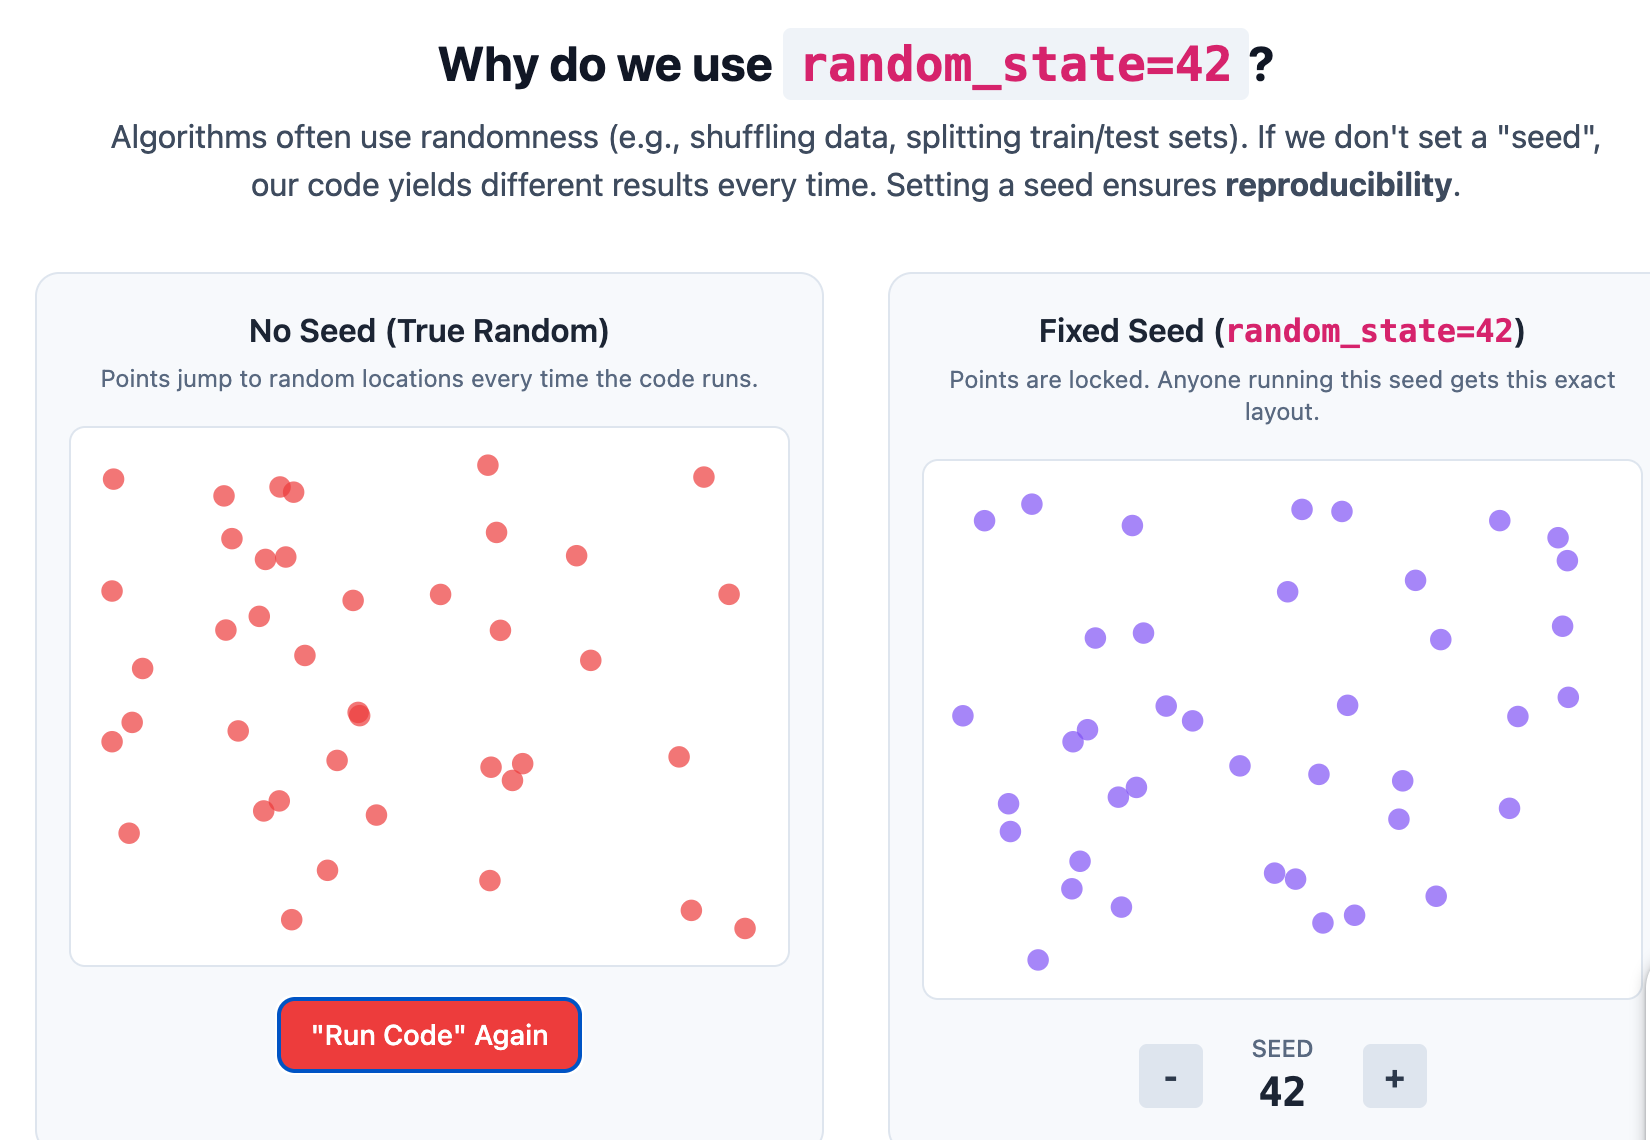

*Why 42?*:  https://www.kaggle.com/discussions/general/541061

In [ ]:
RANDOM_STATE = 42

We CANNOT evaluate a model on the same data it was trained on — it would just memorize. So we put 80% aside for training and 20% for testing. Ratios can be changed upon needs




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)


### Estimation

First we need to create our estimator

In [ ]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)

Then fit learning (training data)

In [ ]:
tree_model.fit(X_train, y_train)


Finally predict test values, which are unseen by model training

In [ ]:
y_pred_tree = tree_model.predict(X_test)


Now we need to evalute our predictions

In [ ]:
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree accuracy on the test set: {acc_tree:.4f}")

In [ ]:
print(classification_report(y_test, y_pred_tree, target_names=class_names))

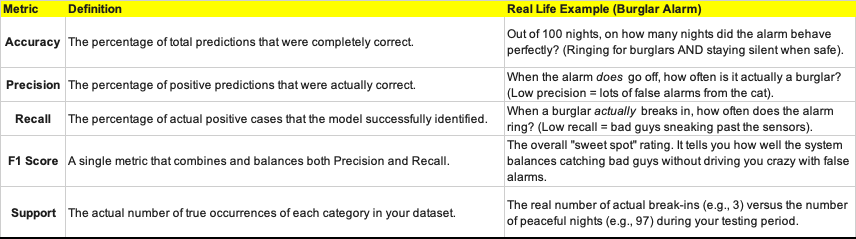

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,         # color nodes by class
    rounded=True,
    fontsize=9,
)
plt.title("Decision Tree (max_depth=4)")
plt.tight_layout()
